In [9]:
# Import required packages

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from shapely.geometry import Point
from scipy.stats import gamma,norm,fisk,wilcoxon
from sklearn.cluster import KMeans
import sys
import gc
from pathlib import Path
import logging
from matplotlib.patches import Patch

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

In [3]:
# Configuration
config = {
    'casr_input_dir': project_root / 'Snow_Drought_Framework' / 'Data'  / 'output_data' / 'CaSR',
    'shapefile': project_root / 'Snow_Drought_Framework' / 'Data' / 'output_data' / 'elevation' / 'Alberta_elevation_combined.shp',
    'output_dir_SWEI': project_root / 'Snow_Drought_Framework' / 'Data' / 'output_data' / 'SWEI',
    'output_plots': project_root / 'Snow_Drought_Framework' / 'Data' / 'output_plots' / 'SWEI'
}

# Functions

In [6]:
def load_basin_data(file_path: str) -> gpd.GeoDataFrame:
    """
    Load basin shapefile data.
    
    Parameters
    ----------
    file_path : str
        Path to the shapefile containing basin data.
        
    Returns
    -------
    geopandas.GeoDataFrame
        GeoDataFrame containing basin data.
    """
    return gpd.read_file(file_path)

def load_csv_data(file_path: str) -> pd.DataFrame:
    """
    Load CSV data.
    
    Parameters
    ----------
    file_path : str
        Path to the CSV file containing data.
        
    Returns
    -------
    pandas.DataFrame
        DataFrame containing the loaded CSV data.
    """
    return pd.read_csv(file_path)

def select_seasonal_data(ts, start_month, end_month, min_year, max_year):
    month = ts.month
    year = ts.year
    if month >= start_month:
        seasonal_year = year
    elif month <= end_month:
        seasonal_year = year - 1
    else:
        return np.nan
    return seasonal_year if (min_year <= seasonal_year <= max_year) else np.nan

def extract_grid_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract per-Grid static metadata.
    """
    return (
        df[["Grid_ID", "lon", "lat", "elev_class"]]
        .drop_duplicates("Grid_ID")
        .set_index("Grid_ID")
    )

def perturb_daily_swe_zeros(
    df: pd.DataFrame,
    swe_col: str = "SWE",
    id_col: str = "Grid_ID",
    seed: int = 42,
    perturb_factor: float = 0.01
) -> pd.DataFrame:
    """
    Perturb exact daily SWE zeros before integration.
    Keeps Grid_ID as a normal column.
    """

    out = df.copy().reset_index(drop=True)

    if id_col not in out.columns:
        raise KeyError(f"{id_col} is not in columns. Columns are: {out.columns.tolist()}")

    out[swe_col] = out[swe_col].astype(float)

    rng = np.random.default_rng(seed)

    for sid, idx in out.groupby(id_col).groups.items():

        vals = out.loc[idx, swe_col]

        valid = vals.notna()
        zero_idx = vals[valid & (vals == 0)].index
        positive_vals = vals[valid & (vals > 0)]

        if len(zero_idx) == 0:
            continue

        if positive_vals.empty:
            continue

        min_positive = positive_vals.min()

        out.loc[zero_idx, swe_col] = (
            rng.uniform(low=1e-6, high=1e-5, size=len(zero_idx))
            * min_positive
            * perturb_factor
        )
    return out

def daily_to_monthly_swe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Daily perturbed SWE → monthly integrated SWE.
    Seasonal_Year is recomputed from time.
    """

    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])

    monthly = (
        out
        .groupby(
            ["Grid_ID", pd.Grouper(key="time", freq="MS")],
            as_index=False
        )
        .agg(
            SWE_monthly=("SWE_perturbed", "sum")
        )
    )

    # Recompute Seasonal_Year (e.g., Oct–Sep water year)
    monthly["Seasonal_Year"] = np.where(
        monthly["time"].dt.month >= 10,
        monthly["time"].dt.year,
        monthly["time"].dt.year - 1
    )
    
    return monthly


def rolling_integrated_swe_by_season(
    monthly_df: pd.DataFrame,
    window_months: int
) -> pd.DataFrame:
    """
    Compute rolling k‑month integrated SWE within each Seasonal_Year.

    • Rolling windows do NOT cross Seasonal_Year boundaries.
    • First (k‑1) months of each season are dropped.
    • Works for any window (3, 6, 8, …).
    """

    out = monthly_df.copy()
    out = out.sort_values(["Grid_ID", "Seasonal_Year", "time"])

    out[f"SWE_{window_months}mo"] = (
        out
        .groupby(["Grid_ID", "Seasonal_Year"])["SWE_monthly"]
        .rolling(window=window_months, min_periods=window_months)
        .sum()
        .reset_index(level=[0, 1], drop=True)
    )

    return out.dropna(subset=[f"SWE_{window_months}mo"])



def gringorten_probabilities(x: np.ndarray) -> np.ndarray:
    """
    Gringorten plotting position with:
    - NaN handling
    - average ranks for ties
    - probability clipping
    """
    x = np.asarray(x, float)
    out = np.full_like(x, np.nan)

    mask = ~np.isnan(x)
    xv = x[mask]

    if xv.size == 0:
        return out

    # ranks with average ties
    order = np.argsort(xv, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(xv) + 1)

    uvals, inv, cnt = np.unique(xv, return_inverse=True, return_counts=True)
    for i, c in enumerate(cnt):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()

    N = float(len(xv))
    p = (ranks - 0.44) / (N + 0.12)
    p = np.clip(p, 1e-12, 1 - 1e-12)

    out[mask] = p
    return out


def compute_swei_for_grid(
    df: pd.DataFrame,
    swe_col: str
) -> pd.DataFrame:
    """
    Compute SWEI for ONE station/grid using calendar-month standardization.
    """

    out = df.copy()
    out["month"] = out["time"].dt.month

    pvals = np.full(len(out), np.nan)
    zvals = np.full(len(out), np.nan)

    for m in range(1, 13):
        idx = out["month"] == m
        vals = out.loc[idx, swe_col]

        if vals.notna().sum() == 0:
            continue

        p = gringorten_probabilities(vals.values)
        z = norm.ppf(p)

        pvals[idx] = p
        zvals[idx] = z

    out["Gringorten_p"] = pvals
    out["SWEI"] = zvals

    return out



def compute_swei(
    df: pd.DataFrame,
    window_months: int = 3,
    seed: int = 42
) -> pd.DataFrame:
    """
    End-to-end SWEI calculation with daily zero perturbation
    before monthly and rolling integration.
    """

    # 0. Extract static metadata
    grid_meta = extract_grid_metadata(df)

    # 1. Prepare daily data
    daily = df.copy()
    daily["time"] = pd.to_datetime(daily["time"])

    # 2. Create perturbed SWE column
    daily["SWE_perturbed"] = daily["SWE"]

    daily = perturb_daily_swe_zeros(
    daily,
    swe_col="SWE_perturbed",
    id_col="Grid_ID",
    seed=seed,
    perturb_factor=0.01
    )

    # 3. Daily → monthly integrated SWE
    monthly = daily_to_monthly_swe(daily)

    # 4. Rolling monthly integration
    integ = rolling_integrated_swe_by_season(monthly, window_months)

    # 5. Compute SWEI per station/grid
    swei = (
        integ
        .groupby("Grid_ID", group_keys=False)
        .apply(
            lambda g: compute_swei_for_grid(
                g,
                swe_col=f"SWE_{window_months}mo"
            )
        )
        .reset_index(drop=True)
    )
    if "Grid_ID" not in swei.columns:
        swei["Grid_ID"] = integ["Grid_ID"].values    
    print(swei.columns.tolist())
    print(swei.head())

    # 6. Reattach static metadata
    swei = swei.reset_index()

    swei = swei.merge(
    grid_meta.reset_index(),
    on="Grid_ID",
    how="left"
)

    return swei

# Select data for winter and combine data for SWEI calculation

In [22]:
files = sorted(config["casr_input_dir"].glob("combined_precip_swe_*.csv"))

dfs = []

for file in files:
    year = int(file.stem.split("_")[-1])
    print("Reading", year)

    df = pd.read_csv(
        file,
        usecols=["Grid_ID", "time", "lat", "lon", "elev_class", "swe", "precip"]
    )

    df["time"] = pd.to_datetime(df["time"])

    # keep winter months only: Oct-May
    df = df[df["time"].dt.month.isin([10, 11, 12, 1, 2, 3, 4, 5])]

    # seasonal year: Oct-Dec belong to same year, Jan-May previous year
    df['Seasonal_Year'] = df['time'].apply(
        lambda ts: select_seasonal_data(ts, start_month=10, end_month=5, min_year=1980, max_year=2023)
    )


    dfs.append(df)

daily_all = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()

print(daily_all.shape)

Reading 1980
Reading 1981
Reading 1982
Reading 1983
Reading 1984
Reading 1985
Reading 1986
Reading 1987
Reading 1988
Reading 1989
Reading 1990
Reading 1991
Reading 1992
Reading 1993
Reading 1994
Reading 1995
Reading 1996
Reading 1997
Reading 1998
Reading 1999
Reading 2000
Reading 2001
Reading 2002
Reading 2003
Reading 2004
Reading 2005
Reading 2006
Reading 2007
Reading 2008
Reading 2009
Reading 2010
Reading 2011
Reading 2012
Reading 2013
Reading 2014
Reading 2015
Reading 2016
Reading 2017
Reading 2018
Reading 2019
Reading 2020
Reading 2021
Reading 2022
Reading 2023
Reading 2024
(71697275, 8)


In [23]:
# drop NaN in Seasonal_Year
daily_all = daily_all.dropna(subset=["Seasonal_Year"])

#rename swe to SWE
daily_all = daily_all.rename(columns={"swe": "SWE"})

# rename precip to Precipitation
daily_all = daily_all.rename(columns={"precip": "Precipitation"})

#remove decimal in Seasonal_Year
daily_all["Seasonal_Year"] = daily_all["Seasonal_Year"].astype(int)

# save daily_all to csv
daily_all.to_csv(config['output_dir_SWEI'] / 'Alberta_casr_daily_all_new.csv', index=False)
display(daily_all.head())

,Grid_ID,time,lat,lon,elev_class,Precipitation,SWE,Seasonal_Year
1003960,1825,1980-10-01,49.0062,-110.4268,1000_1500m,0.000000,0.0,1980
1003961,1846,1980-10-01,49.0298,-110.2956,1000_1500m,0.000000,0.0,1980
1003962,1865,1980-10-01,49.0533,-110.1643,1000_1500m,0.000000,0.0,1980
1003963,1885,1980-10-01,49.0765,-110.0329,1000_1500m,0.008709,0.0,1980
1003964,1842,1980-10-01,49.0211,-110.8567,1000_1500m,0.260985,0.0,1980


# Calculate SWEI

In [15]:
#8-month SWEI
swei_8mo = compute_swei(daily_all, window_months=8, seed=42)
swei_8mo.to_csv(config['output_dir_SWEI'] / 'bow_casr_swei_8mo_new.csv', index=False)

display(swei_8mo.head())

['time', 'SWE_monthly', 'Seasonal_Year', 'SWE_8mo', 'month', 'Gringorten_p', 'SWEI', 'Grid_ID']
        time  SWE_monthly  Seasonal_Year      SWE_8mo  month  Gringorten_p  \
0 1981-05-01     1.246094           1980   899.566558      5      0.239347   
1 1982-05-01    44.561524           1981  2955.971558      5      0.851315   
2 1983-05-01    16.888672           1982   974.116211      5      0.284678   
3 1984-05-01     5.042969           1983  1240.172241      5      0.398005   
4 1985-05-01     2.958984           1984  2701.782105      5      0.783318   

       SWEI  Grid_ID  
0 -0.708404     1823  
1  1.042088     1823  
2 -0.569000     1823  
3 -0.258513     1823  
4  0.783449     1823  


,index,time,SWE_monthly,Seasonal_Year,SWE_8mo,month,Gringorten_p,SWEI,Grid_ID,lon,lat,elev_class
0,0,1981-05-01,1.246094,1980,899.566558,5,0.239347,-0.708404,1823,-112.4088,49.0028,1000_1500m
1,1,1982-05-01,44.561524,1981,2955.971558,5,0.851315,1.042088,1823,-112.4088,49.0028,1000_1500m
2,2,1983-05-01,16.888672,1982,974.116211,5,0.284678,-0.569000,1823,-112.4088,49.0028,1000_1500m
3,3,1984-05-01,5.042969,1983,1240.172241,5,0.398005,-0.258513,1823,-112.4088,49.0028,1000_1500m
4,4,1985-05-01,2.958984,1984,2701.782105,5,0.783318,0.783449,1823,-112.4088,49.0028,1000_1500m


In [17]:
# avaerage SWEI over the Elevation categories, month and seasonal year
swei_8mo_avg = (
    swei_8mo
    .groupby(
        ['elev_class', 'Seasonal_Year','month'],
        as_index=False
    )
    .agg(
        Avg_SWEI_8mo=('SWEI', 'mean')
    )
)

display(swei_8mo_avg.head(15))

,elev_class,Seasonal_Year,month,Avg_SWEI_8mo
0,0_500m,1980,5,-0.319014
1,0_500m,1981,5,0.249791
2,0_500m,1982,5,0.710513
3,0_500m,1983,5,-0.909618
4,0_500m,1984,5,0.544012
5,0_500m,1985,5,0.442175
6,0_500m,1986,5,0.983767
7,0_500m,1987,5,0.022860
8,0_500m,1988,5,1.342846
9,0_500m,1989,5,1.331155


In [21]:
# save swei_8mo_avg to csv
swei_8mo_avg.to_csv(config['output_dir_SWEI'] / 'Alberta_casr_swei_8mo_avg_new.csv', index=False)

In [44]:
#print snow drought years for each elevation category
for elev_cat in swei_8mo_avg['elev_class'].unique():
    elev_data = swei_8mo_avg[swei_8mo_avg['elev_class'] == elev_cat]
    drought_years = elev_data[elev_data['Avg_SWEI_8mo'] <= -0.5]['Seasonal_Year'].unique()
    print(f"Elevation Category: {elev_cat}, Drought Years (Avg SWEI <= -0.5): {drought_years.tolist()}")

# Create a dataframe with drought years for each elevation category
drought_data = []
for elev_cat in swei_8mo_avg['elev_class'].unique():
    elev_data = swei_8mo_avg[swei_8mo_avg['elev_class'] == elev_cat]
    drought_years = elev_data[elev_data['Avg_SWEI_8mo'] <= -0.5]['Seasonal_Year'].unique()
    drought_data.append({
        'elev_class': elev_cat,
        'Drought_Years': sorted(drought_years.tolist())
    })

drought_years_df = pd.DataFrame(drought_data)

# save the drought years dataframe to a CSV file
drought_years_df.to_csv(config["output_dir_SWEI"] / "Drought_Years_by_Elevation.csv", index=False)  

display(drought_years_df)

Elevation Category: 0_500m, Drought Years (Avg SWEI <= -0.5): [1983, 1992, 1997, 1998, 2000, 2001, 2002, 2003, 2005, 2009, 2011, 2014, 2016, 2023]
Elevation Category: 1000_1500m, Drought Years (Avg SWEI <= -0.5): [1987, 1997, 1999, 2000, 2004, 2005, 2011, 2015]
Elevation Category: 1500_2000m, Drought Years (Avg SWEI <= -0.5): [1986, 1987, 1997, 1998, 2000, 2002, 2004, 2005, 2011, 2015]
Elevation Category: 2000_2500m, Drought Years (Avg SWEI <= -0.5): [1987, 1996, 1997, 1998, 2000, 2002, 2003, 2004, 2005, 2007, 2009, 2015]
Elevation Category: 500_1000m, Drought Years (Avg SWEI <= -0.5): [1987, 1992, 1997, 1999, 2000, 2005, 2011, 2016, 2023]


,elev_class,Drought_Years
0,0_500m,"[1983, 1992, 1997, 1998, 2000, 2001, 2002, 200..."
1,1000_1500m,"[1987, 1997, 1999, 2000, 2004, 2005, 2011, 2015]"
2,1500_2000m,"[1986, 1987, 1997, 1998, 2000, 2002, 2004, 200..."
3,2000_2500m,"[1987, 1996, 1997, 1998, 2000, 2002, 2003, 200..."
4,500_1000m,"[1987, 1992, 1997, 1999, 2000, 2005, 2011, 201..."


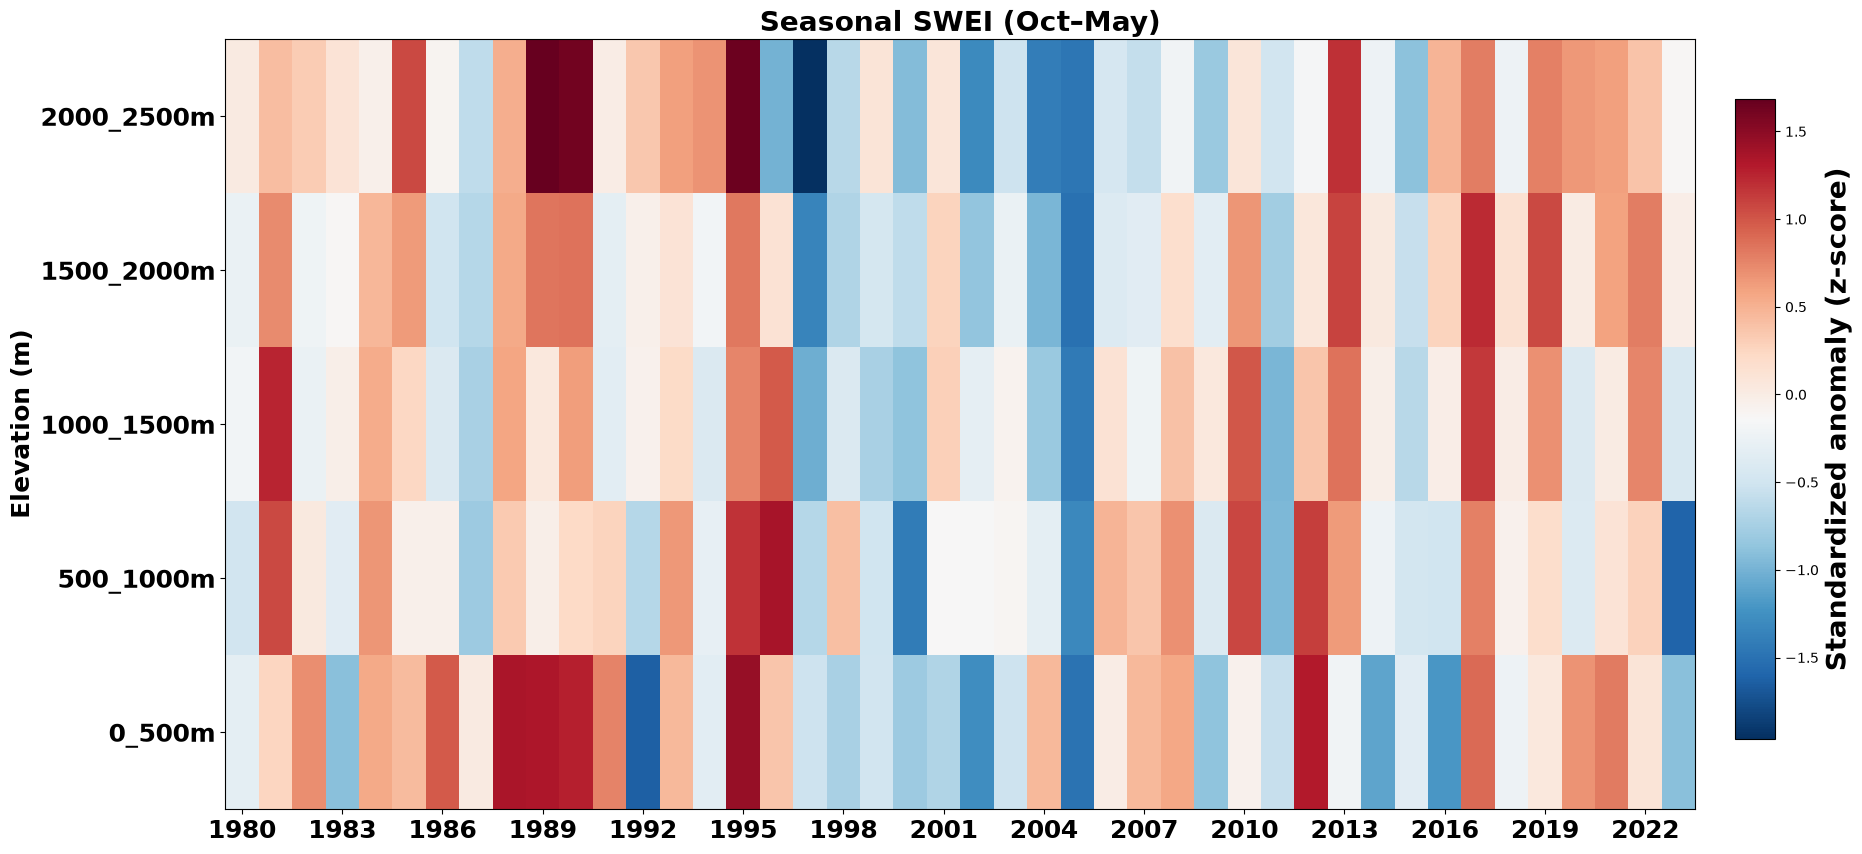

In [43]:
# Define elevation order explicitly
elev_order = ['2000_2500m','1500_2000m','1000_1500m','500_1000m','0_500m']

# Pivot SWEI
swei_mat = swei_8mo_avg.pivot_table(
    index="elev_class",
    columns="Seasonal_Year",
    values="Avg_SWEI_8mo"
).reindex(elev_order)

# ---- Plot ----
fig, axes = plt.subplots(figsize=(20, 10))

im1 = axes.imshow(swei_mat, cmap="RdBu_r", aspect="auto")

axes.set_title("Seasonal SWEI (Oct–May)", fontsize=20, fontweight="bold")
axes.set_ylabel("Elevation (m)", fontsize=18, fontweight="bold")

axes.set_yticks(np.arange(len(swei_mat.index)))
axes.set_yticklabels(swei_mat.index, fontsize=18, fontweight="bold")

years = swei_mat.columns.to_numpy()
step = max(1, len(years)//12)
axes.set_xticks(np.arange(len(years))[::step])
axes.set_xticklabels(years[::step], fontsize=18, fontweight="bold")

fig.subplots_adjust(right=0.86)
cbar_ax = fig.add_axes([0.88, 0.18, 0.02, 0.64])
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label("Standardized anomaly (z-score)", fontsize=20, fontweight="bold")

# save figure
out_file_heatmap = config['output_plots'] / f'SWEI_Alberta_basin_8month_heatmap.png'
fig.savefig(out_file_heatmap, dpi=300, bbox_inches='tight')
plt.show()